In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
# import geopy.distances
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.stats import zscore
import seaborn as sns
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import overlap_utils as ou

In [7]:
## Set data folder to the parent folder with the subfolders for each modality (e.g. alphaearth, dynamicworld, tessera):
data_folder = '../data/'
gfm_mods = ['alphaearth', 'tessera', 'geoclip', 'satclip']

# print(f'Number of samples: {len(list_ids)}')
countries = gpd.read_file('../content/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')


In [8]:
sample_types = ['cropharvest', 'biomass', 'random_sample', 'lc_stratified_sample']

for i_s, sample_type in enumerate(sample_types):
    df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, 
                                            modalities=gfm_mods + ['bioclim', 'human_footprint'] if sample_type in ['lc_stratified_sample', 'random_sample'] else gfm_mods,
                                            zscore_embeddings=False)


alphaearth 3596
tessera 3600
geoclip 3600
satclip 3600
alphaearth 4581
tessera 4571
geoclip 4585
satclip 4585
Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9695
tessera 8901
geoclip 10000
satclip 10000
bioclim 9681
human_footprint 9681
Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9693
tessera 8829
geoclip 10000
satclip 10000
bioclim 9665
human_footprint 9665


In [9]:
df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type='lc_stratified_sample', 
                                            modalities=gfm_mods + ['bioclim', 'human_footprint'],
                                            zscore_embeddings=False)
gdf_all = gpd.GeoDataFrame(df_all, geometry=gpd.points_from_xy(df_all['lon'], df_all['lat']), crs='EPSG:4326')

Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
alphaearth 9693
tessera 8829
geoclip 10000
satclip 10000
bioclim 9665
human_footprint 9665


<Axes: >

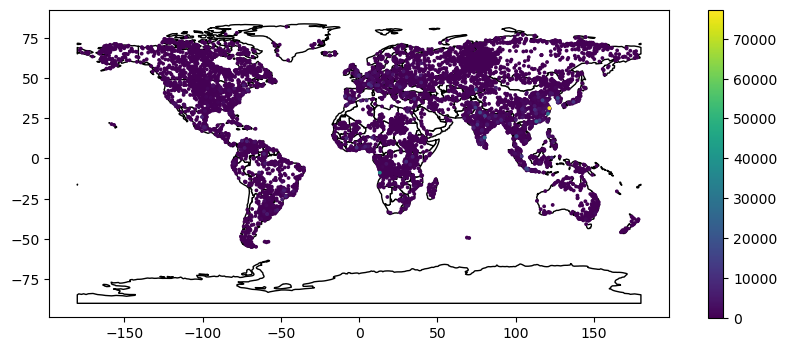

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))
ax_map = ax

countries.plot(ax=ax_map, color="#FFFFFF", edgecolor='black')
col_plot = 'pop_density'
gdf_all.sort_values(by=col_plot, ascending=True).plot(ax=ax_map, 
                column=col_plot, cmap='viridis', markersize=3, legend=True)

# ax_map.set_xlim([-120, -30])
# ax_map.set_ylim([0, 80])

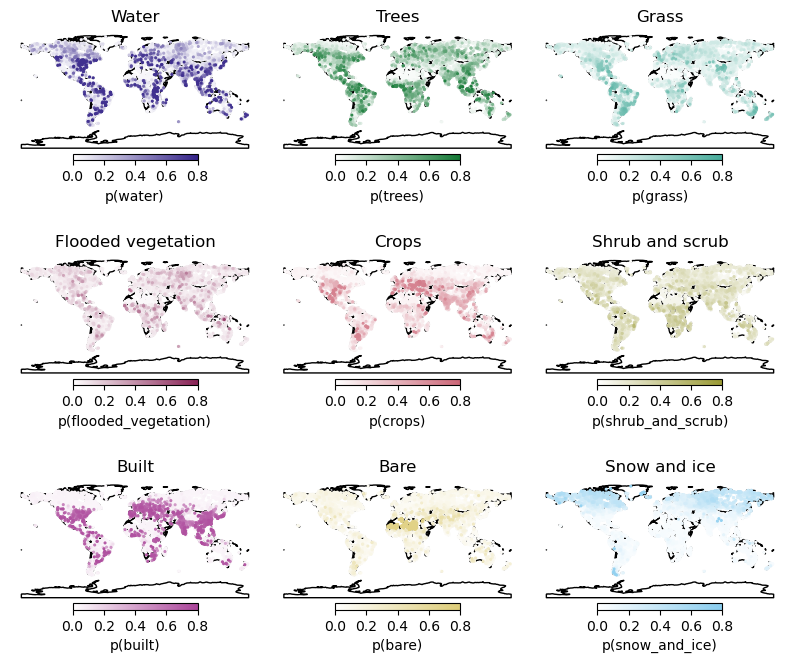

In [11]:
fig, ax = plt.subplots(3, 3, figsize=(10,8), gridspec_kw={'wspace':0.05, 'hspace':0.35})
ax = ax.flatten()
save_fig = False

import matplotlib as mpl
def cap_first_letter(s):
    if len(s) > 0:
        return s[0].upper() + s[1:]
    else:
        return s
    
cmap_dict = du.create_mpl_cmap_dynamic_world()
list_classes = list(cmap_dict['individual'].keys())
for i_plot, ax_map in enumerate(ax):
    if i_plot >= len(list_classes):
        ax[i_plot].axis('off')
        i_plot += 1
        continue
    col_plot = list_classes[i_plot]
    name_plot = cap_first_letter(col_plot.replace('_', ' '))
    
    countries.plot(ax=ax_map, color="#FFFFFF", edgecolor='black')
    gdf_all = gdf_all.sort_values(by=col_plot, ascending=True)
    gdf_all.plot(ax=ax_map, column=col_plot, markersize=1.5, alpha=1,
                    cmap=cmap_dict['individual'][col_plot], vmin=0, vmax=0.8,
                    rasterized=True, legend=True, 
                    legend_kwds={'label': f'p({col_plot})', 'orientation': "horizontal", 'shrink': 0.5, 'pad': -0.0, 'ticks': [0, 0.2, 0.4, 0.6, 0.8]})
    ax[i_plot].set_title(name_plot)
    ax[i_plot].set_axis_off()

if save_fig:
     fig_folder = '../figs/'
     assert os.path.exists(fig_folder) and os.path.isdir(fig_folder), f"Figure folder {fig_folder} does not exist and/or is not a directory."
     fig.savefig(os.path.join(fig_folder, f'lc_data_maps.pdf'), bbox_inches='tight', dpi=150)   